<a href="https://colab.research.google.com/github/xDanilog27/Bussiness-Inteligent/blob/main/Reto_Parcial_II_Modelos_Neuronales_Equidad_de_Genero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Instalación de las librerias y carga de las librerias


In [141]:
!pip install tensorflow #Libreria nativa para el diseño de redes neuronales

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Se procede con la carga de los datos

In [142]:
nxl='/content/drive/MyDrive/Retos/Parcial 2/7. BGD and Cost of Debt - Feb 2023_Int.xlsx'

XDB=pd.read_excel(nxl,sheet_name=0) #Base de datos
XDB = XDB.iloc[:, 4:]

XDB=XDB[['Unnamed: 9', 'Unnamed: 15', 'Unnamed: 21', 'Unnamed: 27',
    'Unnamed: 33', 'Unnamed: 39', 'Unnamed: 45', 'Unnamed: 51',
    'Unnamed: 57', 'Unnamed: 63', 'Unnamed: 69', 'Unnamed: 75',
    'Unnamed: 81', 'Unnamed: 87', 'Unnamed: 93', 'Unnamed: 99']]

XDB.rename(columns={
    'Unnamed: 9': 'ESG_2022',  # ESG Score
    'Unnamed: 15': 'E_2022',   # Environmental Pillar Score
    'Unnamed: 21': 'S_2022',   # Social Pillar Score
    'Unnamed: 27': 'G_2022',   # Governance Pillar Score
    'Unnamed: 33': 'WACCS_2022',  # WACC Short Term Debt Cost
    'Unnamed: 39': 'WACCL_2022',  # WACC Long Term Debt Cost
    'Unnamed: 45': 'BGDP_2022',   # Board Gender Diversity Percent
    'Unnamed: 51': 'BGDP_Score_2022',  # Board Gender Diversity Score
    'Unnamed: 57': 'PBD_2022',  # Policy Board Diversity
    'Unnamed: 63': 'BS_2022',   # Board Size
    'Unnamed: 69': 'FB_2022',   # Female on Board
    'Unnamed: 75': 'IBM_2022',  # Independent Board Members
    'Unnamed: 81': 'IBM_Score_2022',  # Independent Board Members Score
    'Unnamed: 87': 'EMGD_2022',  # Executive Members Gender Diversity Percent
    'Unnamed: 93': 'EMGD_Score_2022',  # Executive Members Gender Diversity Score
    'Unnamed: 99': 'SDG5_2022'  # SDG 5 Gender Equality
}, inplace=True)

XDB = XDB.drop(index=0).reset_index(drop=True)
XDB = XDB.dropna()
display(XDB)


# Separamos las variables por entrada y salida
XD=np.array(XDB[['ESG_2022', 'E_2022', 'S_2022', 'G_2022',
                   'BGDP_Score_2022', 'BS_2022', 'FB_2022',
                   'IBM_Score_2022', 'EMGD_2022']])
yd=np.array(XDB[['WACCS_2022']])


#Se procede con la normalización de las variables
XDn=XD/np.max(XD,axis=0) #axis=0 que lo haga por columnas
ydn=yd #/np.max(yd,axis=0) #No es necesario normalizar la variable de salida
print("Los datos de entrada son:\n",XDn)


,ESG_2022,E_2022,S_2022,G_2022,WACCS_2022,WACCL_2022,BGDP_2022,BGDP_Score_2022,PBD_2022,BS_2022,FB_2022,IBM_2022,IBM_Score_2022,EMGD_2022,EMGD_Score_2022,SDG5_2022
0,47.373394,3.176714,44.427314,69.111111,0.027338,0.016627,20.000000,50.000000,1,10.0,20.000000,90.000000,90.000000,25.000000,80.000000,0.0
1,64.897646,57.131000,85.083044,51.859924,0.020482,0.014328,14.285714,63.235294,0,7.0,14.285714,37.500000,61.764706,14.285714,42.647059,1.0
2,11.404420,1.591586,16.934558,20.897059,0.041818,0.030225,0.000000,14.285714,0,7.0,0.000000,0.000000,7.142857,16.666667,58.571429,0.0
3,42.611203,25.046615,50.820884,52.583333,0.031550,0.023253,0.000000,14.285714,0,11.0,0.000000,18.181818,22.857143,22.222222,71.428571,1.0
4,42.373123,30.937338,52.415617,33.111111,0.023380,0.014210,33.333333,90.000000,1,12.0,33.333333,83.333333,30.000000,23.076923,50.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
459,76.279473,72.708116,77.866015,78.965723,0.014214,0.008788,25.000000,92.372881,0,12.0,25.000000,20.000000,2.542373,16.666667,88.135593,0.0
460,71.269788,67.458020,68.422327,80.382514,0.017743,0.012642,11.111111,68.644068,0,9.0,11.111111,44.444444,33.050847,18.181818,92.372881,1.0
461,24.632129,29.579521,25.454124,17.626667,0.039538,0.024945,0.000000,17.600000,1,7.0,0.000000,44.444444,55.600000,0.000000,26.800000,0.0
462,54.678722,62.513668,70.520216,31.751456,0.029246,0.020100,0.000000,17.164179,0,6.0,0.000000,33.333333,32.835821,0.000000,26.865672,1.0


Los datos de entrada son:
 [[0.51843136 0.03229427 0.460467   ... 0.33333333 0.9044335  0.5       ]
 [0.71020823 0.58079004 0.88184342 ... 0.23809524 0.62068966 0.28571429]
 [0.12480442 0.01617996 0.17551827 ... 0.         0.07178044 0.33333333]
 ...
 [0.26956203 0.30070349 0.26381933 ... 0.         0.55873892 0.        ]
 [0.5983773  0.63550989 0.73090695 ... 0.         0.32997574 0.        ]
 [0.31790275 0.39062044 0.26736792 ... 0.12820513 0.16181014 0.        ]]


3. Modelo Autoecoder SHORT


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_78"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_156 (Dense)               │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_157 (Dense)               │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100 (400.00 B)

 Trainable params: 100 (400.00 B)

 Non-trainable params: 0 (0.00 B)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
La correlación entre yp-ydn es:
           0         1
0  1.000000  0.770004
1  0.770004  1.000000


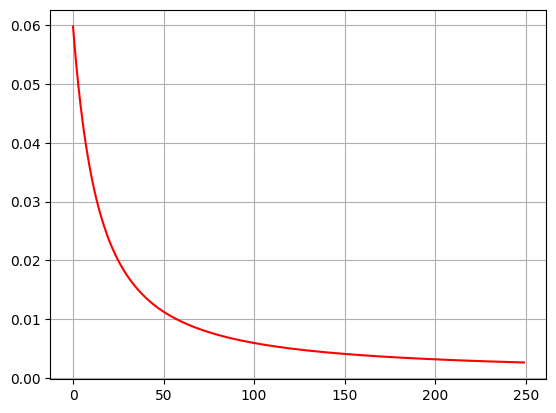

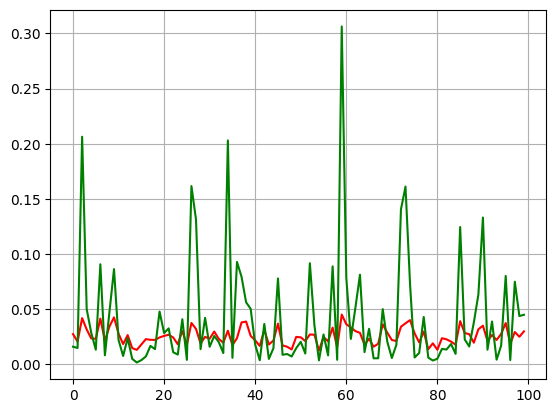

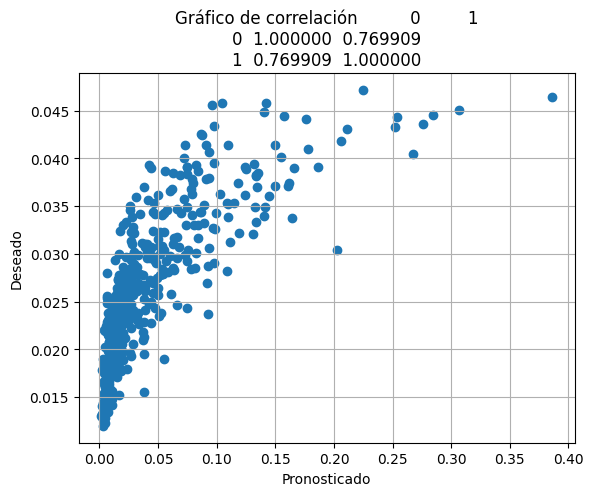

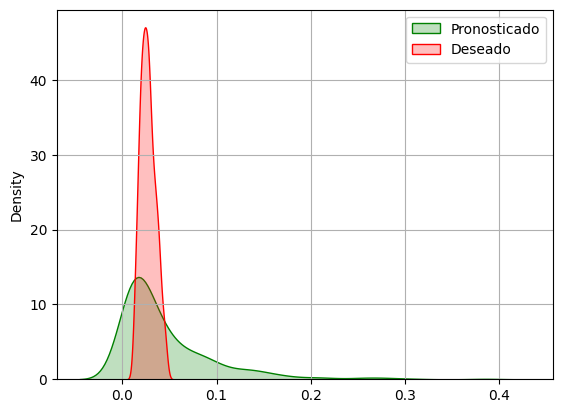

Los efectos independientes son:
 [[-1.7383538 ]
 [-1.2327191 ]
 [ 0.5574975 ]
 [-0.8612096 ]
 [-1.1285154 ]
 [-0.9553728 ]
 [ 0.37708217]
 [-1.8042266 ]
 [-0.9907081 ]]
ESG_2022: -1.7384
E_2022: -1.2327
S_2022: 0.5575
G_2022: -0.8612
BGDP_Score_2022: -1.1285
BS_2022: -0.9554
FB_2022: 0.3771
IBM_Score_2022: -1.8042
EMGD_2022: -0.9907


In [143]:
madaline=tf.keras.Sequential([
  tf.keras.layers.Dense(units=10,input_shape=(9,),use_bias=False, activation='relu'),
  tf.keras.layers.Dense(units=1,use_bias=False,activation='sigmoid')])

madaline.load_weights('/content/drive/MyDrive/Retos/Parcial 2/7. pesos_sigmoid_WACCS.weights.h5')

madaline.summary()
madaline.compile(optimizer='sgd',loss='mse')
history2=madaline.fit(XDn,ydn,epochs=250, verbose=0)

#Evaluamos el modelo
yp2=madaline.predict(XDn)
dfcorr2=pd.DataFrame(np.column_stack((yp2,ydn)))
print("La correlación entre yp-ydn es:\n",dfcorr2.corr())

#Caida del error en el aprendizaje
ek=history2.history['loss'] #Muestra el error en el aprendizaje

plt.figure()
plt.plot(ek,'r')
plt.grid(True)
plt.show()

#Gráficamos los resultados
plt.figure()
plt.plot(ydn[0:100,],'r',label='Deseado')
plt.plot(yp[0:100],'g',label='Pronosticado')
plt.grid(True)
plt.show()

#Gráfico de correlación
#Debe haber una predominancia de la diagonal principal
plt.figure()
plt.scatter(yp,ydn)
plt.grid(True)

plt.xlabel('Pronosticado')
plt.ylabel('Deseado')
plt.title('Gráfico de correlación'+str(dfcorr.corr()))
plt.show()

#Gráfico de distribuciones
plt.figure()
sns.kdeplot(x=yp.flatten(),label='Pronosticado', fill=True, color='g')
sns.kdeplot(x=ydn.flatten(),label='Deseado', fill=True, color='r')
plt.grid(True)
plt.legend()
plt.show()

#Efectos independientes
WC=madaline.get_weights()
W=WC[0]; C=WC[1]
a=W@C #Estos son los efectos independientes
print("Los efectos independientes son:\n",a)

# Nombres de las variables (en el orden correcto)
variables = ['ESG_2022', 'E_2022', 'S_2022', 'G_2022',
             'BGDP_Score_2022', 'BS_2022', 'FB_2022',
             'IBM_Score_2022', 'EMGD_2022']

# Mostrar efectos con nombre
for nombre, valor in zip(variables, a):
    print(f"{nombre}: {valor[0]:.4f}")






In [144]:
Xnp=[[59.29,16.17,83.88,42.66,72.01,6,16.67,3.36,26.87]]
Xnpn=Xnp/np.max(XD, axis=0)
print("Los datos de entrada son:\n", Xnpn)

ypnp2=madaline.predict(Xnpn)
print("El score estimado es:\n", ypnp2)

0.048

Los datos de entrada son:
 [[0.64884088 0.16438317 0.86937446 0.4485495  0.72364729 0.28571429
  0.27783333 0.03376552 0.5374    ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
El score estimado es:
 [[0.05338634]]


0.048

3. Modelo Autoecoder WACC Long term

,ESG_2022,E_2022,S_2022,G_2022,WACCS_2022,WACCL_2022,BGDP_2022,BGDP_Score_2022,PBD_2022,BS_2022,FB_2022,IBM_2022,IBM_Score_2022,EMGD_2022,EMGD_Score_2022,SDG5_2022
0,47.373394,3.176714,44.427314,69.111111,0.027338,0.016627,20.000000,50.000000,1,10.0,20.000000,90.000000,90.000000,25.000000,80.000000,0.0
1,64.897646,57.131000,85.083044,51.859924,0.020482,0.014328,14.285714,63.235294,0,7.0,14.285714,37.500000,61.764706,14.285714,42.647059,1.0
2,11.404420,1.591586,16.934558,20.897059,0.041818,0.030225,0.000000,14.285714,0,7.0,0.000000,0.000000,7.142857,16.666667,58.571429,0.0
3,42.611203,25.046615,50.820884,52.583333,0.031550,0.023253,0.000000,14.285714,0,11.0,0.000000,18.181818,22.857143,22.222222,71.428571,1.0
4,42.373123,30.937338,52.415617,33.111111,0.023380,0.014210,33.333333,90.000000,1,12.0,33.333333,83.333333,30.000000,23.076923,50.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
459,76.279473,72.708116,77.866015,78.965723,0.014214,0.008788,25.000000,92.372881,0,12.0,25.000000,20.000000,2.542373,16.666667,88.135593,0.0
460,71.269788,67.458020,68.422327,80.382514,0.017743,0.012642,11.111111,68.644068,0,9.0,11.111111,44.444444,33.050847,18.181818,92.372881,1.0
461,24.632129,29.579521,25.454124,17.626667,0.039538,0.024945,0.000000,17.600000,1,7.0,0.000000,44.444444,55.600000,0.000000,26.800000,0.0
462,54.678722,62.513668,70.520216,31.751456,0.029246,0.020100,0.000000,17.164179,0,6.0,0.000000,33.333333,32.835821,0.000000,26.865672,1.0


Los datos de entrada son:
 [[0.51843136 0.03229427 0.460467   ... 0.33333333 0.9044335  0.5       ]
 [0.71020823 0.58079004 0.88184342 ... 0.23809524 0.62068966 0.28571429]
 [0.12480442 0.01617996 0.17551827 ... 0.         0.07178044 0.33333333]
 ...
 [0.26956203 0.30070349 0.26381933 ... 0.         0.55873892 0.        ]
 [0.5983773  0.63550989 0.73090695 ... 0.         0.32997574 0.        ]
 [0.31790275 0.39062044 0.26736792 ... 0.12820513 0.16181014 0.        ]]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_79"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_158 (Dense)               │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_159 (Dense)               │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100 (400.00 B)

 Trainable params: 100 (400.00 B)

 Non-trainable params: 0 (0.00 B)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
La correlación entre yp-ydn es:
           0         1
0  1.000000  0.810321
1  0.810321  1.000000


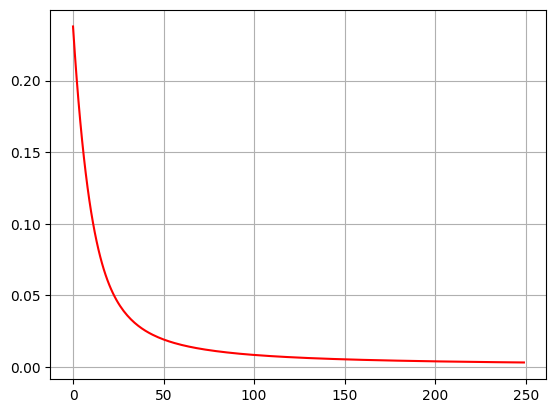

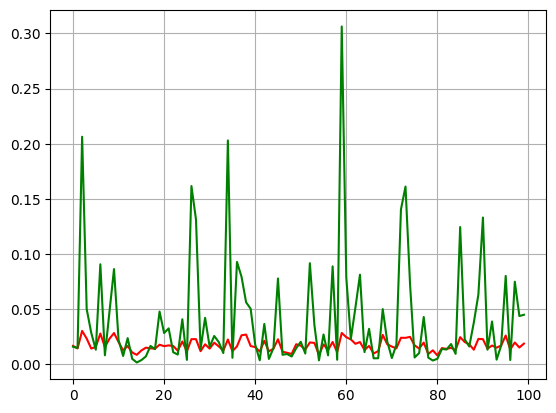

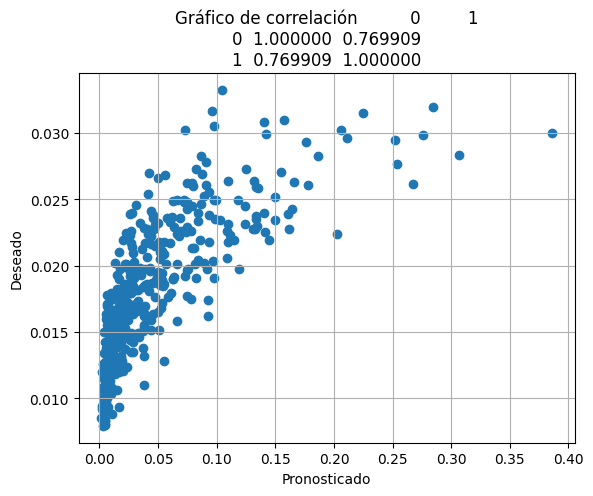

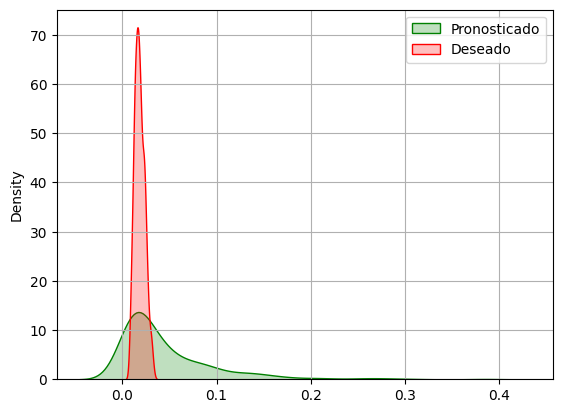

Los efectos independientes son:
 [[-1.389891  ]
 [-0.6500899 ]
 [-1.4321406 ]
 [-0.4612559 ]
 [-0.85017836]
 [-1.7531148 ]
 [-0.8319544 ]
 [-0.81058764]
 [-0.40461364]]
ESG_2022: -1.3899
E_2022: -0.6501
S_2022: -1.4321
G_2022: -0.4613
BGDP_Score_2022: -0.8502
BS_2022: -1.7531
FB_2022: -0.8320
IBM_Score_2022: -0.8106
EMGD_2022: -0.4046


In [145]:
nxl='/content/drive/MyDrive/Retos/Parcial 2/7. BGD and Cost of Debt - Feb 2023_Int.xlsx'

XDB=pd.read_excel(nxl,sheet_name=0) #Base de datos
XDB = XDB.iloc[:, 4:]

XDB=XDB[['Unnamed: 9', 'Unnamed: 15', 'Unnamed: 21', 'Unnamed: 27',
    'Unnamed: 33', 'Unnamed: 39', 'Unnamed: 45', 'Unnamed: 51',
    'Unnamed: 57', 'Unnamed: 63', 'Unnamed: 69', 'Unnamed: 75',
    'Unnamed: 81', 'Unnamed: 87', 'Unnamed: 93', 'Unnamed: 99']]

XDB.rename(columns={
    'Unnamed: 9': 'ESG_2022',  # ESG Score
    'Unnamed: 15': 'E_2022',   # Environmental Pillar Score
    'Unnamed: 21': 'S_2022',   # Social Pillar Score
    'Unnamed: 27': 'G_2022',   # Governance Pillar Score
    'Unnamed: 33': 'WACCS_2022',  # WACC Short Term Debt Cost
    'Unnamed: 39': 'WACCL_2022',  # WACC Long Term Debt Cost
    'Unnamed: 45': 'BGDP_2022',   # Board Gender Diversity Percent
    'Unnamed: 51': 'BGDP_Score_2022',  # Board Gender Diversity Score
    'Unnamed: 57': 'PBD_2022',  # Policy Board Diversity
    'Unnamed: 63': 'BS_2022',   # Board Size
    'Unnamed: 69': 'FB_2022',   # Female on Board
    'Unnamed: 75': 'IBM_2022',  # Independent Board Members
    'Unnamed: 81': 'IBM_Score_2022',  # Independent Board Members Score
    'Unnamed: 87': 'EMGD_2022',  # Executive Members Gender Diversity Percent
    'Unnamed: 93': 'EMGD_Score_2022',  # Executive Members Gender Diversity Score
    'Unnamed: 99': 'SDG5_2022'  # SDG 5 Gender Equality
}, inplace=True)

XDB = XDB.drop(index=0).reset_index(drop=True)
XDB = XDB.dropna()
display(XDB)


# Separamos las variables por entrada y salida
XD=np.array(XDB[['ESG_2022', 'E_2022', 'S_2022', 'G_2022',
                   'BGDP_Score_2022', 'BS_2022', 'FB_2022',
                   'IBM_Score_2022', 'EMGD_2022']])
yd=np.array(XDB[['WACCL_2022']])


#Se procede con la normalización de las variables
XDn=XD/np.max(XD,axis=0) #axis=0 que lo haga por columnas
ydn=yd#/np.max(yd,axis=0) #No es necesario normalizar la variable de salida
print("Los datos de entrada son:\n",XDn)


madaline=tf.keras.Sequential([
  tf.keras.layers.Dense(units=10,input_shape=(9,),use_bias=False, activation='relu'),
  tf.keras.layers.Dense(units=1,use_bias=False,activation='sigmoid')])

madaline.load_weights('/content/drive/MyDrive/Retos/Parcial 2/7. pesos_sigmoid_WACCL.weights.h5')

madaline.summary()
madaline.compile(optimizer='sgd',loss='mse')
history2=madaline.fit(XDn,ydn,epochs=250, verbose=0)

#Evaluamos el modelo
yp2=madaline.predict(XDn)
dfcorr2=pd.DataFrame(np.column_stack((yp2,ydn)))
print("La correlación entre yp-ydn es:\n",dfcorr2.corr())

#Caida del error en el aprendizaje
ek=history2.history['loss'] #Muestra el error en el aprendizaje

plt.figure()
plt.plot(ek,'r')
plt.grid(True)
plt.show()


#Gráficamos los resultados
plt.figure()
plt.plot(ydn[0:100,],'r',label='Deseado')
plt.plot(yp[0:100],'g',label='Pronosticado')
plt.grid(True)
plt.show()

#Gráfico de correlación
#Debe haber una predominancia de la diagonal principal
plt.figure()
plt.scatter(yp,ydn)
plt.grid(True)

plt.xlabel('Pronosticado')
plt.ylabel('Deseado')
plt.title('Gráfico de correlación'+str(dfcorr.corr()))
plt.show()

#Gráfico de distribuciones
plt.figure()
sns.kdeplot(x=yp.flatten(),label='Pronosticado', fill=True, color='g')
sns.kdeplot(x=ydn.flatten(),label='Deseado', fill=True, color='r')
plt.grid(True)
plt.legend()
plt.show()


#Efectos independientes
WC=madaline.get_weights()
W=WC[0]; C=WC[1]
a=W@C #Estos son los efectos independientes
print("Los efectos independientes son:\n",a)

# Nombres de las variables (en el orden correcto)
variables = ['ESG_2022', 'E_2022', 'S_2022', 'G_2022',
             'BGDP_Score_2022', 'BS_2022', 'FB_2022',
             'IBM_Score_2022', 'EMGD_2022']

# Mostrar efectos con nombre
for nombre, valor in zip(variables, a):
    print(f"{nombre}: {valor[0]:.4f}")


In [146]:
Xnp=[[59.29,16.17,83.88,42.66,72.01,6,16.67,3.36,26.87]]
Xnpn=Xnp/np.max(XD, axis=0)
print("Los datos de entrada son:\n", Xnpn)

ypnp2=madaline.predict(Xnpn)
print("El score estimado es:\n", ypnp2)

0.018


Los datos de entrada son:
 [[0.64884088 0.16438317 0.86937446 0.4485495  0.72364729 0.28571429
  0.27783333 0.03376552 0.5374    ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
El score estimado es:
 [[0.02087128]]


0.018

4. Modelo Autoecoder- Usando Madaline

In [148]:
# Modelo Autoecoder- Usando Madaline

nxl='/content/drive/MyDrive/Retos/Parcial 2/7. BGD and Cost of Debt - Feb 2023_Int.xlsx'

XDB=pd.read_excel(nxl,sheet_name=0) #Base de datos
XDB = XDB.iloc[:, 4:]

XDB=XDB[['Unnamed: 9', 'Unnamed: 15', 'Unnamed: 21', 'Unnamed: 27',
    'Unnamed: 33', 'Unnamed: 39', 'Unnamed: 45', 'Unnamed: 51',
    'Unnamed: 57', 'Unnamed: 63', 'Unnamed: 69', 'Unnamed: 75',
    'Unnamed: 81', 'Unnamed: 87', 'Unnamed: 93', 'Unnamed: 99']]

XDB.rename(columns={
    'Unnamed: 9': 'ESG_2022',  # ESG Score
    'Unnamed: 15': 'E_2022',   # Environmental Pillar Score
    'Unnamed: 21': 'S_2022',   # Social Pillar Score
    'Unnamed: 27': 'G_2022',   # Governance Pillar Score
    'Unnamed: 33': 'WACCS_2022',  # WACC Short Term Debt Cost
    'Unnamed: 39': 'WACCL_2022',  # WACC Long Term Debt Cost
    'Unnamed: 45': 'BGDP_2022',   # Board Gender Diversity Percent
    'Unnamed: 51': 'BGDP_Score_2022',  # Board Gender Diversity Score
    'Unnamed: 57': 'PBD_2022',  # Policy Board Diversity
    'Unnamed: 63': 'BS_2022',   # Board Size
    'Unnamed: 69': 'FB_2022',   # Female on Board
    'Unnamed: 75': 'IBM_2022',  # Independent Board Members
    'Unnamed: 81': 'IBM_Score_2022',  # Independent Board Members Score
    'Unnamed: 87': 'EMGD_2022',  # Executive Members Gender Diversity Percent
    'Unnamed: 93': 'EMGD_Score_2022',  # Executive Members Gender Diversity Score
    'Unnamed: 99': 'SDG5_2022'  # SDG 5 Gender Equality
}, inplace=True)

XDB = XDB.drop(index=0).reset_index(drop=True)
XDB = XDB.dropna()

# Separamos las variables por entrada y salida
XD=np.array(XDB[['ESG_2022', 'E_2022', 'S_2022', 'G_2022',
                   'BGDP_Score_2022', 'BS_2022', 'FB_2022',
                   'IBM_Score_2022', 'EMGD_2022','WACCS_2022','WACCL_2022']])

#Se procede con la normalización de las variables
XDn=XD/np.max(XD,axis=0) # axis=0 que lo haga por columnas
print("Los datos de entrada son:\n",XDn)

madaline=tf.keras.Sequential([
  tf.keras.layers.Dense(units=10,input_shape=(11,),use_bias=False, activation='relu'),
  tf.keras.layers.Dense(units=11,use_bias=False,activation='relu')])

madaline.load_weights('/content/drive/MyDrive/Retos/Parcial 2/7. pesos_autoencoder_BGD.weights.h5')

madaline.summary()
madaline.compile(optimizer='sgd',loss='mse') #sdg: Gradiente Descenso
                                             #mse: Error Salida Modelo
history=madaline.fit(XDn,XDn,epochs=250, verbose=0)     #misma entrada: XDn - misma salida: XDn
XDnp=madaline.predict(XDn)                   #Pronóstico de la salida

df=pd.DataFrame(np.column_stack((XDn,XDnp)))
dfc=pd.DataFrame(df.corr())    #Determino las correlaciones
dfc.to_excel('correlaciones.xlsx')

#Evaluamos el modelo
yp2=madaline.predict(XDn)
dfcorr2=pd.DataFrame(np.column_stack((yp2,ydn)))
print("La correlación entre yp-ydn es:\n",dfcorr2.corr())


#Como se obtienen las ecuaciones para el modelo
WC=madaline.get_weights()
W=WC[0]; C=WC[1]
a=W@C
dfm=pd.DataFrame(a.T)
dfm.columns=['ESG_2022', 'E_2022', 'S_2022', 'G_2022',
                   'BGDP_Score_2022', 'BS_2022', 'FB_2022',
                   'IBM_Score_2022', 'EMGD_2022','WACCS_2022','WACCL_2022']
display(dfm)


# Correlaciones entre las 11 originales (XDn)
df_original = pd.DataFrame(XDn, columns=['ESG_2022', 'E_2022', 'S_2022', 'G_2022',
                                         'BGDP_Score_2022', 'BS_2022', 'FB_2022',
                                         'IBM_Score_2022', 'EMGD_2022','WACCS_2022','WACCL_2022'])
dfc_original = df_original.corr()
dfc_original.to_excel('correlaciones_entrada.xlsx')



Los datos de entrada son:
 [[0.51843136 0.03229427 0.460467   ... 0.5        0.57974484 0.50000431]
 [0.71020823 0.58079004 0.88184342 ... 0.28571429 0.43433742 0.43086299]
 [0.12480442 0.01617996 0.17551827 ... 0.33333333 0.88680849 0.9089242 ]
 ...
 [0.26956203 0.30070349 0.26381933 ... 0.         0.83844845 0.75013436]
 [0.5983773  0.63550989 0.73090695 ... 0.         0.62018779 0.60443375]
 [0.31790275 0.39062044 0.26736792 ... 0.         0.72233017 0.64259422]]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_162 (Dense)               │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_163 (Dense)               │ (None, 11)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220 (880.00 B)

 Trainable params: 220 (880.00 B)

 Non-trainable params: 0 (0.00 B)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
La correlación entre yp-ydn es:
           0         1         2         3         4         5         6   \
0   1.000000  0.917959  0.961953  0.957966  0.794354 -0.470220  0.200913   
1   0.917959  1.000000  0.831813  0.914407  0.627964 -0.496733  0.334418   
2   0.961953  0.831813  1.000000  0.954658  0.876680 -0.396703  0.207443   
3   0.957966  0.914407  0.954658  1.000000  0.866892 -0.412919  0.384784   
4   0.794354  0.627964  0.876680  0.866892  1.000000 -0.144027  0.512638   
5  -0.470220 -0.496733 -0.396703 -0.412919 -0.144027  1.000000  0.177711   
6   0.200913  0.334418  0.207443  0.384784  0.512638  0.177711  1.000000   
7   0.706492  0.831876  0.649783  0.815071  0.704626 -0.215842  0.790344   
8   0.862276  0.714051  0.919982  0.930908  0.920832 -0.303467  0.302230   
9  -0.592990 -0.490678 -0.487080 -0.393111 -0.126811  0.535003  0.468763   
10 -0.641763 -0.621782 -0.614413 -0.676586 -0.49387

,ESG_2022,E_2022,S_2022,G_2022,BGDP_Score_2022,BS_2022,FB_2022,IBM_Score_2022,EMGD_2022,WACCS_2022,WACCL_2022
0,0.402196,-0.083992,0.545785,0.064947,0.293057,-0.158399,0.221970,0.277167,-0.129316,-0.158457,0.417402
1,-0.213109,0.089092,0.398372,0.279609,0.004522,0.203911,0.350487,0.474426,-0.454843,0.174113,0.032471
2,0.299539,-0.378783,0.165038,0.532189,-0.044697,-0.480769,0.002171,0.503300,-0.237618,0.242854,-0.271913
3,-0.171999,-0.010838,0.468148,0.348863,0.056595,-0.136028,0.109271,0.586260,-0.116030,-0.135335,0.005652
4,-0.264788,0.789133,0.328243,0.059650,0.453160,0.009475,-0.086324,-0.325260,0.773719,-0.038426,0.005537
5,0.010766,-0.522448,-0.520075,-0.473352,0.496292,-0.167706,0.281143,-0.241400,0.077138,0.573729,0.002926
6,-0.014583,-0.204243,-0.070514,0.127852,0.073710,-0.410106,0.304006,0.276780,-0.278698,0.002158,0.232608
7,-0.242687,-0.330478,0.211736,0.109983,0.165954,-0.438327,0.507491,0.684248,-0.426365,0.090734,0.426514
8,-0.135393,0.372680,0.447803,0.009197,0.100457,0.109669,-0.240722,0.089435,0.282535,-0.676527,0.302699
9,-0.324097,0.338725,0.156962,0.142119,0.342945,0.090831,0.239319,-0.080759,0.150602,0.435389,0.306909


Análisis de Resultados

WACC Short Term
Correlación entre yp y ydn: 0.0675, lo cual indica una relación débil entre ambas variables. Si analizamos la grafica ella muestra un comportamiento decreciente, lo que sugiere que a medida que aumenta el plazo, el efecto marginal del costo disminuye rápidamente.